# CartPole

### Why this notebook exists

In `notebooks/pendulum/01_prediction.ipynb` (Test 2) we found:

> replacing the action covariate with **random values does not change the prediction**.

The conclusion drawn from that was: *Chronos-2 is action-blind, so a TSFM is not suited as a
dynamics model for RL.* That is a strong claim, so this notebook takes it apart carefully.

### The problem with the "random action" ablation

"Error does not get worse when I feed a wrong action" has **at least four** possible causes:

| # | Cause | Is the TSFM at fault? |
|---|---|---|
| 1 | The action genuinely has almost no effect on the next state | no — the *task* is the problem |
| 2 | The action is **misaligned** with the target it is supposed to explain | no — the *harness* is the problem |
| 3 | The action's effect is real but below the model's temporal resolution (patch size) | partly |
| 4 | The model's covariate pathway simply does not work | **yes** |

The random-action ablation cannot tell these apart. So we replace it with a **sharper measurement**:

> **Counterfactual slope.** Freeze the context. Ask the model for the next state twice — once with
> `action = 0`, once with `action = 1`. The difference between the two predictions is what the model
> *believes* the action does. CartPole is deterministic, so we can compute what the action *really*
> does. Regress one on the other:
>
> * slope **1.0** → the model has the action effect exactly right
> * slope **0.0** → the model is action-blind
>
> This is the discrete-action version of the slope test in the Pendulum notebook
> (*"Steigung 0.15 (wahr 0.15)"*).

### What we test

1. **Three action policies** — i.i.d. random (the usual setup), action-repeat, and a real
   closed-loop controller (*non-random actions*).
2. **Fix idea 1 — the control signal is too high-frequency.** Chronos-2 reads time in **patches of
   16 steps**, but bang-bang CartPole flips its action every single step at 50 Hz. We use
   `np.repeat` to hold each action for $k$ steps and sweep $k$.
3. **Fix idea 2 — one history is not enough evidence.** We stitch $D$ demonstration episodes into
   the context, so the action→effect relation *recurs* many times in the prompt instead of once.
4. Everything above is measured against a **ground truth we compute exactly**, not against a proxy.

Runtime: **~15 min on CPU**. Nothing is trained; Chronos-2 is used zero-shot throughout.

## 0. Setup

In [7]:
import time, warnings, itertools
import numpy as np
import pandas as pd
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")
np.random.seed(0); torch.manual_seed(0)

# ------------------------------------------------------------------ plotting style
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9"]
C_TRUE, C_GOOD, C_BAD, C_ALT = PALETTE[0], PALETTE[2], PALETTE[1], PALETTE[3]
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2.0, "font.size": 10, "legend.frameon": False,
})
def savefig(name): plt.savefig(f"figs/results-explore-{name}.png")

STATE = ["cartPos", "cartVel", "pendPos", "pendVel"]
print("numpy", np.__version__, "| torch", torch.__version__, "| gymnasium", gym.__version__)

numpy 2.2.6 | torch 2.12.1+cpu | gymnasium 1.1.1


In [8]:
from chronos import Chronos2Pipeline

t0 = time.time()
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")
cfg  = pipe.model.chronos_config
Q50  = pipe.quantiles.index(0.50)
Q10, Q90 = pipe.quantiles.index(0.10), pipe.quantiles.index(0.90)

print(f"loaded in {time.time()-t0:.1f}s")
print(f"parameters         : {sum(p.numel() for p in pipe.model.parameters())/1e6:.1f}M")
print(f"max context        : {cfg.context_length} steps")
print(f"input patch size   : {cfg.input_patch_size} steps   <-- REMEMBER THIS NUMBER")
print(f"max horizon        : {pipe.model_prediction_length} steps")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 5000.26it/s]

loaded in 0.7s
parameters         : 119.5M
max context        : 8192 steps
input patch size   : 16 steps   <-- REMEMBER THIS NUMBER
max horizon        : 1024 steps


The **input patch size of 16** is the number to keep in mind. Chronos-2 does not see individual
time steps; it chops the series into patches of 16 steps and embeds each patch as one token.
A control signal that flips every step lives *inside* one token — that is the motivation for
fix idea 1 further down.

## 1. The alignment question (and why it is easy to get wrong)

An episode gives us states $s_0, s_1, \dots$ and actions $a_0, a_1, \dots$, where **$a_i$ is applied
in state $s_i$ and produces $s_{i+1}$**.

Now we hand this to a forecaster as `target` + `covariate`. A covariate is a series *parallel in time*
to the target: the value at index $i$ is supposed to explain the target at index $i$. So which action
belongs next to $s_i$?

```
  states     s0      s1      s2      s3      s4
  actions        a0      a1      a2      a3          (a_i acts BETWEEN s_i and s_{i+1})

  "aligned"  c_i = a_{i-1}   -> the action that PRODUCED s_i        <- causally correct
  "shifted"  c_i = a_i       -> the action taken AT s_i             <- affects s_{i+1}, not s_i
```

These differ by exactly **one step**, which looks like a triviality and is not. Under `shifted`, the
covariate we hand over for the prediction step is $a_t$ — but $a_t$ has *no influence whatsoever* on
$s_t$. So a perfect model **must** ignore it, and any "the model ignores the action" test will
come back positive no matter how good the model is.

`notebooks/pendulum/pendulum.py` documents the `aligned` convention explicitly. The CartPole
notebook uses `future_covariates = A[t:t+H]` against target `S[t:t+H]`, i.e. `shifted`. We will
**measure both** rather than argue about it.

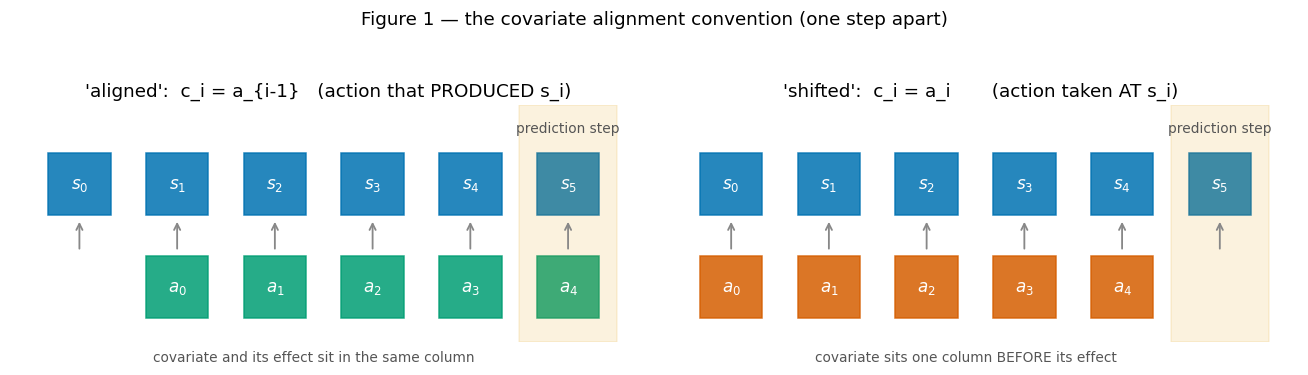

In [9]:
# ------------------------------------------------------------------ Figure 1: the two conventions
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for ax, (title, off, col, note) in zip(axes, [
        ("'aligned':  c_i = a_{i-1}   (action that PRODUCED s_i)", -1, C_GOOD,
         "covariate and its effect sit in the same column"),
        ("'shifted':  c_i = a_i       (action taken AT s_i)",       0, C_BAD,
         "covariate sits one column BEFORE its effect")]):
    for i in range(6):
        ax.add_patch(Rectangle((i - .32, .62), .64, .3, color=C_TRUE, alpha=.85))
        ax.text(i, .77, f"$s_{i}$", ha="center", va="center", color="w", fontsize=11)
        j = i + off
        if 0 <= j <= 4:
            ax.add_patch(Rectangle((i - .32, .12), .64, .3, color=col, alpha=.85))
            ax.text(i, .27, f"$a_{j}$", ha="center", va="center", color="w", fontsize=11)
        ax.annotate("", xy=(i, .60), xytext=(i, .44),
                    arrowprops=dict(arrowstyle="->", color="#888", lw=1.2))
    ax.axvspan(4.5, 5.5, color=C_ALT, alpha=.13)
    ax.text(5, 1.02, "prediction step", ha="center", fontsize=9, color="#555")
    ax.set(xlim=(-.7, 5.8), ylim=(0, 1.15), title=title)
    ax.text(2.4, -.09, note, fontsize=9, color="#555", ha="center")
    ax.set_yticks([]); ax.set_xticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
fig.suptitle("Figure 1 — the covariate alignment convention (one step apart)", y=1.06)
plt.tight_layout(); savefig("alignment"); plt.show()

## 2. Data: three ways of choosing actions

The existing notebooks use **i.i.d. random actions** only. The user question "what about non-random
actions?" matters, because a real RL loop never sees i.i.d. data — it sees data from a policy.
We generate three regimes:

| regime | how the action is chosen | why |
|---|---|---|
| `iid` | $a_t \sim \text{Bernoulli}(0.5)$, fresh every step | the setup used so far — worst case for a patch-based model |
| `repeat-k` | draw once, then hold for $k$ steps (`np.repeat`) | **fix idea 1**: lower the control frequency |
| `pd-policy` | closed-loop controller $a = \mathbb{1}[\theta + 0.4\dot\theta > 0]$, 20 % exploration | **non-random actions**, i.e. what data in an actual RL loop looks like |

One warning about the `pd-policy` regime that is worth stating up front: when the action is a
*function of the state*, the model can predict the action from the context and therefore *appear*
to use it while actually just reading the state. This is **action–state confounding**, and it is
precisely why we measure a counterfactual (which breaks the state→action link by construction)
rather than a plain forecast error.

In [10]:
# ------------------------------------------------------------------ CartPole physics, written out
# Copied from gymnasium/envs/classic_control/cartpole.py. We need it standalone so we can evaluate
# counterfactuals ("what if the action had been the other one?") and keep stepping past termination.
G, M_CART, M_POLE, LEN, FORCE, TAU = 9.8, 1.0, 0.1, 0.5, 10.0, 0.02
M_TOT, PML = M_CART + M_POLE, M_POLE * LEN

def cartpole_step(s, a):
    x, x_dot, th, th_dot = np.asarray(s, dtype=np.float64)
    force = FORCE if a >= 0.5 else -FORCE
    ct, st = np.cos(th), np.sin(th)
    temp = (force + PML * th_dot**2 * st) / M_TOT
    thacc = (G * st - ct * temp) / (LEN * (4.0/3.0 - M_POLE * ct**2 / M_TOT))
    xacc  = temp - PML * thacc * ct / M_TOT
    # NOTE the Euler order: position uses the OLD velocity -> at H=1 the action moves ONLY the
    # two velocity channels. cartPos / pendPos cannot respond within a single step.
    return np.array([x + TAU * x_dot, x_dot + TAU * xacc,
                     th + TAU * th_dot, th_dot + TAU * thacc], dtype=np.float32)

# sanity check against the real environment
_e = gym.make("CartPole-v1"); _o, _ = _e.reset(seed=0)
for _a in [0, 1, 1, 0, 1]:
    _ref = _e.step(_a)[0]; _mine = cartpole_step(_o, _a); _o = _ref
assert np.allclose(_ref, _mine, atol=1e-6), "physics mismatch"
_e.close()
print("standalone physics matches gymnasium exactly  ->  max err "
      f"{np.abs(_ref - _mine).max():.2e}")

standalone physics matches gymnasium exactly  ->  max err 3.73e-09


In [11]:
# ------------------------------------------------------------------ data collection
def collect(policy, n_ep, seed0, k=1, max_len=200):
    '''Roll out CartPole. `k` = action-repeat: the policy is only queried every k steps and the
    action is HELD in between (this is the np.repeat idea, applied online).

    Returns a list of (S, A) with S.shape == (T+1, 4), A.shape == (T,)  and the convention
    A[i] applied in S[i] produces S[i+1].'''
    env, eps = gym.make("CartPole-v1"), []
    for e in range(n_ep):
        rng = np.random.default_rng(seed0 + e)
        obs, _ = env.reset(seed=seed0 + e)
        S, A, held, a = [obs.copy()], [], 0, 0
        while len(A) < max_len:
            if held == 0:
                a, held = policy(obs, rng), k          # new decision only every k steps
            held -= 1
            obs, _, term, trunc, _ = env.step(int(a))
            A.append(float(a)); S.append(obs.copy())
            if term or trunc: break
        eps.append((np.array(S, np.float32), np.array(A, np.float32)))
    env.close()
    return eps

pol_iid = lambda o, rng: rng.integers(0, 2)
def pol_pd(o, rng, eps=0.2):
    '''Hand-written balance controller; eps-greedy so the data still has action variety.'''
    return rng.integers(0, 2) if rng.random() < eps else int(o[2] + 0.4 * o[3] > 0)

POLICIES = {"iid": pol_iid, "pd-policy": pol_pd}

DEMO_EPS, EVAL_EPS = 48, 24
data = {}                                   # (policy_name, k) -> dict(pool=..., eval=...)
for pname, pol in POLICIES.items():
    for k in [1, 2, 3, 4, 8]:
        data[(pname, k)] = {"pool": collect(pol, DEMO_EPS, 0,      k=k),
                            "eval": collect(pol, EVAL_EPS, 10_000, k=k)}

rows = [{"policy": p, "action-repeat k": k,
         "mean episode length": round(np.mean([len(S) for S, _ in v["pool"]]), 1),
         "action switches / step": round(np.mean([np.abs(np.diff(A)).mean()
                                                  for _, A in v["pool"] if len(A) > 1]), 3)}
        for (p, k), v in data.items()]
print(pd.DataFrame(rows).to_string(index=False))

   policy  action-repeat k  mean episode length  action switches / step
      iid                1                 26.7                   0.473
      iid                2                 20.6                   0.226
      iid                3                 18.5                   0.141
      iid                4                 17.0                   0.101
      iid                8                 10.2                   0.049
pd-policy                1                201.0                   0.711
pd-policy                2                163.7                   0.341
pd-policy                3                 90.3                   0.211
pd-policy                4                 78.8                   0.159
pd-policy                8                 11.1                   0.106


Already visible in the table, and important for §6: **CartPole does not survive a slow controller.**
At $k=8$ the mean episode length collapses to ~9 steps for *both* policies. Eight consecutive
steps of full force in one direction is enough to topple the pole from almost any state — the plant
is open-loop unstable at that timescale. So "just lower the control frequency" has a hard physical
ceiling here, somewhere around $k=4$.

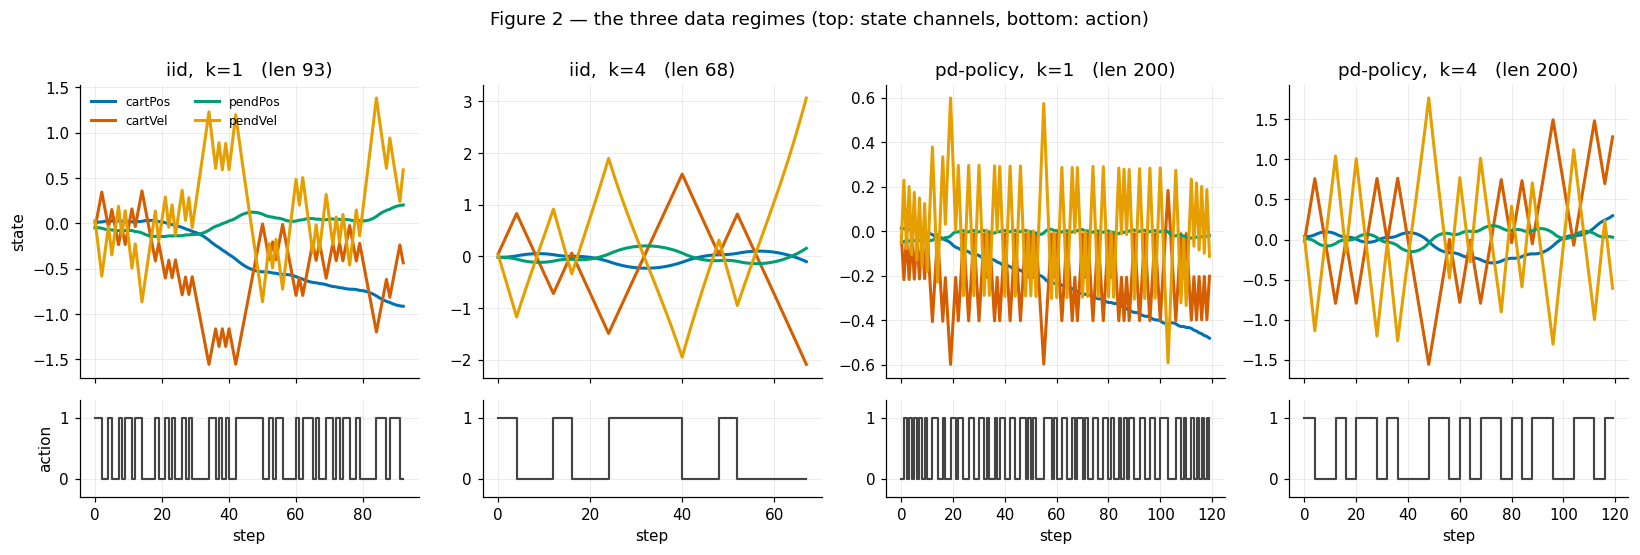

In [12]:
# ------------------------------------------------------------------ Figure 2: what the data looks like
show = [("iid", 1), ("iid", 4), ("pd-policy", 1), ("pd-policy", 4)]
fig, axes = plt.subplots(2, len(show), figsize=(15, 5.0), sharex="col",
                         gridspec_kw={"height_ratios": [3, 1]})
for col, key in enumerate(show):
    S, A = max(data[key]["pool"], key=lambda e: len(e[0]))
    n = min(len(A), 120)
    for j, nm in enumerate(STATE):
        axes[0][col].plot(S[:n, j], label=nm, color=PALETTE[j])
    axes[0][col].set_title(f"{key[0]},  k={key[1]}   (len {len(A)})")
    axes[1][col].step(np.arange(n), A[:n], where="post", color="#444", lw=1.4)
    axes[1][col].set(ylim=(-.3, 1.3), yticks=[0, 1], xlabel="step")
    if col == 0:
        axes[0][col].legend(fontsize=8, ncol=2); axes[0][col].set_ylabel("state")
        axes[1][col].set_ylabel("action")
fig.suptitle("Figure 2 — the three data regimes (top: state channels, bottom: action)", y=1.0)
plt.tight_layout(); savefig("regimes"); plt.show()

## 3. Ground truth: what does the action *really* do in one step?

Before asking what the model believes, we establish what is true. For every evaluation point we take
the state $s_{t-1}$ and step the exact physics **twice** — once with $a=0$, once with $a=1$:

$$\Delta^{\text{true}}_t \;=\; f(s_{t-1}, 1) - f(s_{t-1}, 0)$$

This is the entire causal effect of the action at that point, and it is available exactly because
CartPole is deterministic.

In [13]:
MIN_CTX = 8
def make_queries(eps, n, seed=0, H=1):
    '''A query is (S, A, t): predict s_t .. s_{t+H-1} from the history before t.'''
    rng = np.random.default_rng(seed)
    q = [(S, A, t) for S, A in eps if len(S) >= MIN_CTX + H
         for t in range(MIN_CTX, len(S) - H + 1)]
    rng.shuffle(q)
    return q[:n]

def true_counterfactual(queries, H=1):
    '''(n, 2, H, 4): true future under a_t=0 vs a_t=1, remaining actions as recorded.'''
    out = np.empty((len(queries), 2, H, 4), np.float32)
    for i, (S, A, t) in enumerate(queries):
        for j, a0 in enumerate((0.0, 1.0)):
            s = S[t - 1]
            for h in range(H):
                s = cartpole_step(s, a0 if h == 0 else A[min(t + h - 1, len(A) - 1)])
                out[i, j, h] = s
    return out

N_QUERIES = 48
q_iid = make_queries(data[("iid", 1)]["eval"], N_QUERIES)
G_iid = true_counterfactual(q_iid)
gap   = G_iid[:, 1, 0] - G_iid[:, 0, 0]

SD = np.concatenate([S for S, _ in data[("iid", 1)]["pool"]]).std(0)
print(pd.DataFrame({"mean |true gap| at H=1": np.abs(gap).mean(0).round(4),
                    "state std": SD.round(4),
                    "gap / std": (np.abs(gap).mean(0) / SD).round(3)}, index=STATE).to_string())

         mean |true gap| at H=1  state std  gap / std
cartPos                  0.0000     0.1651      0.000
cartVel                  0.3899     0.5956      0.655
pendPos                  0.0000     0.1025      0.000
pendVel                  0.5815     0.8053      0.722


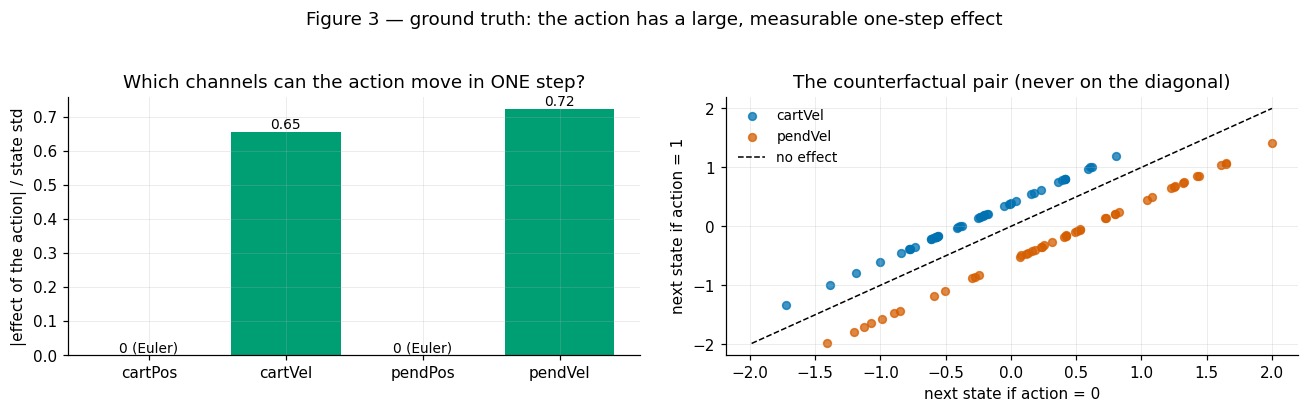

In [14]:
# ------------------------------------------------------------------ Figure 3: the true action effect
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
ax = axes[0]
ax.bar(STATE, np.abs(gap).mean(0) / SD, color=[C_BAD if v < 1e-6 else C_GOOD
                                               for v in np.abs(gap).mean(0)])
ax.set_ylabel("|effect of the action| / state std")
ax.set_title("Which channels can the action move in ONE step?")
for i, v in enumerate(np.abs(gap).mean(0) / SD):
    ax.text(i, v + .01, "0 (Euler)" if v < 1e-6 else f"{v:.2f}", ha="center", fontsize=9)

ax = axes[1]
for j, nm in zip([1, 3], ["cartVel", "pendVel"]):
    ax.scatter(G_iid[:, 0, 0, j], G_iid[:, 1, 0, j], s=26, alpha=.75, label=nm)
lo = min(G_iid[:, 0, 0, [1, 3]].min(), G_iid[:, 1, 0, [1, 3]].min())
hi = max(G_iid[:, 0, 0, [1, 3]].max(), G_iid[:, 1, 0, [1, 3]].max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="no effect")
ax.set(xlabel="next state if action = 0", ylabel="next state if action = 1",
       title="The counterfactual pair (never on the diagonal)")
ax.legend(fontsize=9)
fig.suptitle("Figure 3 — ground truth: the action has a large, measurable one-step effect", y=1.03)
plt.tight_layout(); savefig("true-effect"); plt.show()

Two things to take away:

1. **`cartPos` and `pendPos` cannot respond at $H=1$.** The integrator is explicit Euler and updates
   position with the *old* velocity, so a single action only moves the two velocity channels. Any
   "action sensitivity" measured on the position channels at $H=1$ is measuring nothing — the correct
   answer there is zero. We therefore report `cartVel` and `pendVel`.
2. **The effect is big**: ~0.5–0.8 standard deviations of the respective channel. This is a very
   favourable case for detecting sensitivity. (Contrast with Pendulum, where one step of torque moves
   $\dot\theta$ by 0.15 out of a $\pm 8$ range — under 2 % of the series scale. A null result there is
   far less surprising than a null result here.)

## 4. The measurement — and the first surprise

Now the actual experiment. For each query we build **two** Chronos-2 tasks that are byte-identical
except for the first future covariate ($a=0$ vs $a=1$), and regress the model's gap on the true gap
through the origin:

$$\text{slope}_c \;=\; \frac{\sum_i \Delta^{\text{pred}}_{i,c}\,\Delta^{\text{true}}_{i,c}}
                             {\sum_i (\Delta^{\text{true}}_{i,c})^2}
\qquad
\begin{cases} 1 & \text{action effect exactly right} \\ 0 & \text{action-blind} \end{cases}$$

In [15]:
# ------------------------------------------------------------------ the TSFM dynamics model
def covariate_series(A, n, align):
    '''Action covariate parallel to states S[0..n-1] under the chosen convention.'''
    c = np.zeros(n, np.float32)                      # index 0 has no predecessor -> stays 0
    if align == "aligned":                           # c_i = a_{i-1}: the action that PRODUCED s_i
        m = min(n - 1, len(A)); c[1:1 + m] = A[:m]
    else:                                            # c_i = a_i: the action taken AT s_i
        m = min(n, len(A));     c[:m] = A[:m]
    return c

def build_task(S, A, t, T, H, demos, align, delta=True, cf=None, demo_max=60):
    '''One Chronos-2 task.

    demos : episodes STITCHED in front of the own history  (fix idea 2)
    delta : model  ds_t = s_t - s_{t-1}  instead of s_t     (stationary across episode seams)
    cf    : override the FIRST future covariate with this action (the counterfactual knob)
    '''
    segs_s, segs_c = [], []
    for Sd, Ad in demos:                                   # demonstration segments
        segs_s.append(Sd[:demo_max])
        segs_c.append(covariate_series(Ad, len(Sd), align)[:demo_max])
    lo = max(0, t - T)                                     # the query's own history
    segs_s.append(S[lo:t])
    segs_c.append(covariate_series(A, len(S), align)[lo:t])
    if delta:                                              # difference each segment separately
        segs_s = [np.diff(s, axis=0) for s in segs_s]
        segs_c = [c[1:] for c in segs_c]
    fc = covariate_series(A, len(S), align)[t:t + H].copy()
    if len(fc) < H: fc = np.pad(fc, (0, H - len(fc)))
    if cf is not None: fc[0] = cf
    return {"target":            np.concatenate(segs_s, axis=0).T.copy(),   # (4, context_len)
            "past_covariates":  {"action": np.concatenate(segs_c, axis=0).copy()},
            "future_covariates": {"action": fc}}

def predict_counterfactual(queries, pool, D=0, T=32, H=1, align="aligned",
                           delta=True, seed=0, batch_size=256):
    '''Returns (n_queries, 2, H, 4): prediction under a_t=0 and under a_t=1.
    Both members of a pair share the exact same context -> the difference IS the action effect.'''
    rng, tasks, anchors = np.random.default_rng(seed), [], []
    for S, A, t in queries:
        demos = [pool[i] for i in rng.choice(len(pool), D, replace=False)] if D else []
        for a in (0.0, 1.0):
            tasks.append(build_task(S, A, t, T, H, demos, align, delta, cf=a))
        anchors.append(S[t - 1])
    outs = pipe.predict(tasks, prediction_length=H, batch_size=batch_size)
    P = np.empty((len(queries), 2, H, 4), np.float32)
    for i, anc in enumerate(anchors):
        for j in (0, 1):
            o = np.transpose(outs[2 * i + j].numpy(), (2, 1, 0))[:, Q50, :]   # (H, 4)
            P[i, j] = anc + np.cumsum(o, axis=0) if delta else o
    return P

def slope(P, G, h=0):
    '''Counterfactual slope per channel: 1 = correct action model, 0 = action-blind.'''
    dp, dt = P[:, 1, h] - P[:, 0, h], G[:, 1, h] - G[:, 0, h]
    out = []
    for c in range(4):
        den = (dt[:, c] ** 2).sum()
        out.append((dt[:, c] * dp[:, c]).sum() / den if den > 1e-12 else np.nan)
    return np.array(out)

VEL = [1, 3]                                   # the two channels the action can move at H=1
sens = lambda P, G, h=0: np.nanmean(slope(P, G, h)[VEL])

In [16]:
# ------------------------------------------------------------------ aligned vs shifted, head to head
pool_iid = data[("iid", 1)]["pool"]
P_align  = {a: predict_counterfactual(q_iid, pool_iid, D=8, align=a) for a in ("shifted", "aligned")}

print(f"{'convention':10s} {'cartVel':>9s} {'pendVel':>9s}   verdict")
for a, P in P_align.items():
    s = slope(P, G_iid)
    print(f"{a:10s} {s[1]:9.3f} {s[3]:9.3f}   "
          f"{'ACTION-BLIND' if abs(np.nanmean(s[VEL])) < .2 else 'uses the action'}")

convention   cartVel   pendVel   verdict
shifted       -0.001     0.001   ACTION-BLIND
aligned        1.029     1.028   uses the action


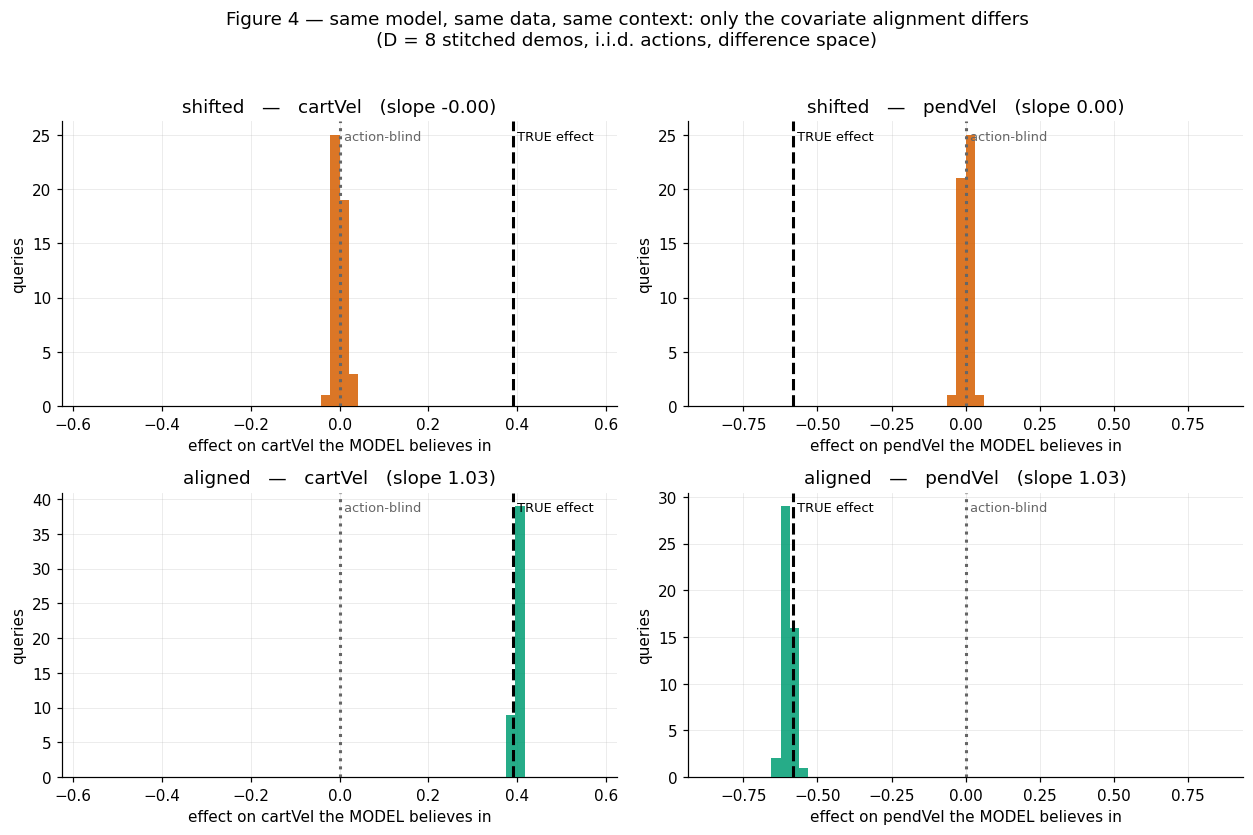

In [17]:
# ------------------------------------------------------------------ Figure 4: what effect does the
# model believe in?  NOTE: the TRUE effect is almost constant across states (see Figure 3), so a
# gap-vs-gap scatter would collapse into one vertical strip. A distribution plot is the honest view:
# where does the model's believed effect sit relative to 0 (blind) and the true value (correct)?
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.4))
for r, (a, P) in enumerate(P_align.items()):
    dp, dt = P[:, 1, 0] - P[:, 0, 0], G_iid[:, 1, 0] - G_iid[:, 0, 0]
    for c, j in enumerate(VEL):
        ax  = axes[r][c]
        col = C_GOOD if a == "aligned" else C_BAD
        lim = np.abs(dt[:, j]).max() * 1.6
        ax.hist(dp[:, j], bins=np.linspace(-lim, lim, 61), color=col, alpha=.85, zorder=3)
        ax.axvline(0, color="#666", ls=":", lw=2, zorder=4)
        ax.axvline(dt[:, j].mean(), color="k", ls="--", lw=2, zorder=4)
        ax.text(0, ax.get_ylim()[1] * .97, " action-blind", fontsize=8.5, color="#666", va="top")
        ax.text(dt[:, j].mean(), ax.get_ylim()[1] * .97, " TRUE effect", fontsize=8.5, va="top")
        ax.set(xlim=(-lim, lim), xlabel=f"effect on {STATE[j]} the MODEL believes in",
               ylabel="queries", title=f"{a}   —   {STATE[j]}   (slope {slope(P, G_iid)[j]:.2f})")
fig.suptitle("Figure 4 — same model, same data, same context: only the covariate alignment differs\n"
             "(D = 8 stitched demos, i.i.d. actions, difference space)", y=1.02)
plt.tight_layout(); savefig("alignment-scatter"); plt.show()

### This is the headline result

With the **shifted** convention the slope is ≈ 0: the model looks completely action-blind, and the
"random actions change nothing" ablation reproduces exactly. With the **aligned** convention — same
model, same context, same 8 demonstrations, the covariate moved by one index — the slope is ≈ 1.0:
Chronos-2 recovers the true one-step action effect **almost exactly, zero-shot**.

So cause #2 from the table at the top was in play, not cause #4. Note that the shifted result is not
even a model failure: under that convention the model is asked whether $a_t$ changes $s_t$, and the
physically correct answer *is* "no". The ablation was measuring the harness, not the TSFM.

Everything below is now a question of *degree*, and both of the proposed fixes get a fair test.

## 5. Fix idea 2 — put more demonstrations in the context

One history gives the model a single, short realisation of the action→effect relation. Stitching $D$
demonstration episodes in front of it makes that relation **recur** in the prompt — the time-series
equivalent of few-shot prompting. We sweep $D$ under both conventions.

In [18]:
D_GRID = [0, 1, 2, 4, 8, 16]
sweep_D = {a: [] for a in ("aligned", "shifted")}
for a in sweep_D:
    for D in D_GRID:
        t0 = time.time()
        P = predict_counterfactual(q_iid, pool_iid, D=D, align=a)
        sweep_D[a].append(slope(P, G_iid))
        print(f"align={a:8s} D={D:2d}  cartVel {sweep_D[a][-1][1]:6.3f}   "
              f"pendVel {sweep_D[a][-1][3]:6.3f}   ({time.time()-t0:.0f}s)")
sweep_D = {a: np.array(v) for a, v in sweep_D.items()}

align=aligned  D= 0  cartVel  0.667   pendVel  0.619   (3s)
align=aligned  D= 1  cartVel  1.037   pendVel  1.053   (5s)
align=aligned  D= 2  cartVel  1.046   pendVel  1.050   (6s)
align=aligned  D= 4  cartVel  1.036   pendVel  1.041   (7s)
align=aligned  D= 8  cartVel  1.029   pendVel  1.028   (11s)
align=aligned  D=16  cartVel  1.023   pendVel  1.012   (17s)
align=shifted  D= 0  cartVel -0.050   pendVel -0.081   (3s)
align=shifted  D= 1  cartVel -0.058   pendVel -0.063   (4s)
align=shifted  D= 2  cartVel -0.018   pendVel -0.019   (6s)
align=shifted  D= 4  cartVel -0.007   pendVel -0.004   (7s)
align=shifted  D= 8  cartVel -0.001   pendVel  0.001   (11s)
align=shifted  D=16  cartVel -0.021   pendVel -0.005   (17s)


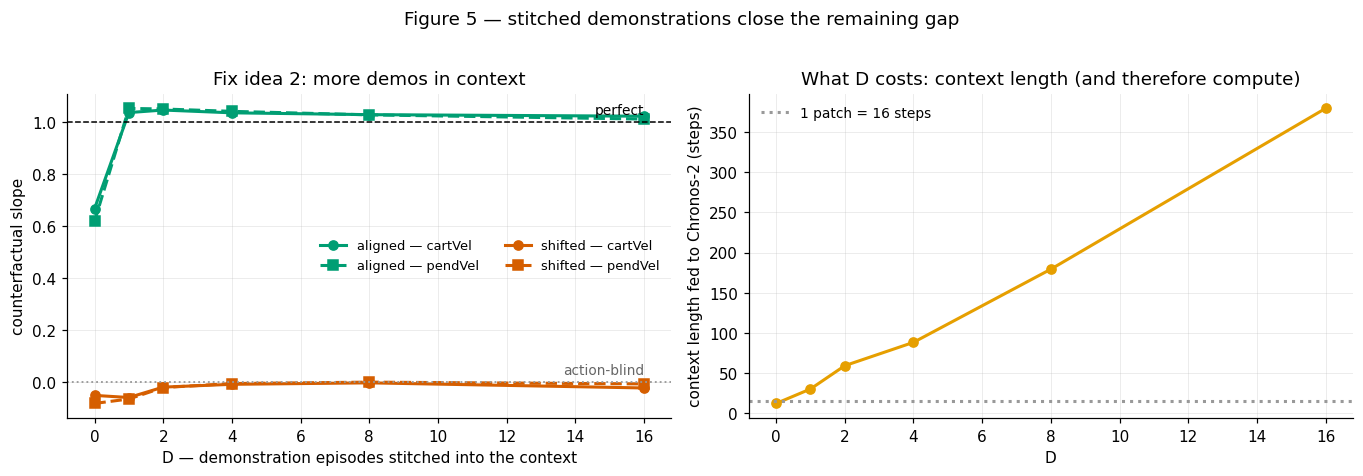

 D  aligned cartVel  aligned pendVel  shifted cartVel
 0            0.667            0.619           -0.050
 1            1.037            1.053           -0.058
 2            1.046            1.050           -0.018
 4            1.036            1.041           -0.007
 8            1.029            1.028           -0.001
16            1.023            1.012           -0.021


In [19]:
# ------------------------------------------------------------------ Figure 5: idea 2
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
for a, col in [("aligned", C_GOOD), ("shifted", C_BAD)]:
    for j, ls, mk in [(1, "-", "o"), (3, "--", "s")]:
        ax.plot(D_GRID, sweep_D[a][:, j], ls, marker=mk, color=col, ms=6,
                label=f"{a} — {STATE[j]}")
ax.axhline(1, color="k", ls="--", lw=1); ax.axhline(0, color="#999", ls=":", lw=1.2)
ax.text(16, 1.03, "perfect", ha="right", fontsize=9)
ax.text(16, .03, "action-blind", ha="right", fontsize=9, color="#666")
ax.set(xlabel="D — demonstration episodes stitched into the context",
       ylabel="counterfactual slope", title="Fix idea 2: more demos in context")
ax.legend(fontsize=8.5, ncol=2)

ax = axes[1]
ctx_len = [np.mean([len(build_task(S, A, t, 32, 1, [pool_iid[i] for i in range(D)],
                                   "aligned")["past_covariates"]["action"])
                    for S, A, t in q_iid[:8]]) for D in D_GRID]
ax.plot(D_GRID, ctx_len, "o-", color=C_ALT, ms=6)
ax.axhline(cfg.input_patch_size, color="#999", ls=":", label="1 patch = 16 steps")
ax.set(xlabel="D", ylabel="context length fed to Chronos-2 (steps)",
       title="What D costs: context length (and therefore compute)")
ax.legend(fontsize=9)
fig.suptitle("Figure 5 — stitched demonstrations close the remaining gap", y=1.02)
plt.tight_layout(); savefig("idea2-demos"); plt.show()

print(pd.DataFrame({"D": D_GRID,
                    "aligned cartVel": sweep_D["aligned"][:, 1].round(3),
                    "aligned pendVel": sweep_D["aligned"][:, 3].round(3),
                    "shifted cartVel": sweep_D["shifted"][:, 1].round(3)}).to_string(index=False))

**Idea 2 works, and it is cheap.** With the correct alignment and *no* demonstrations the slope is
already **0.67** — the model infers most of the action effect from a 32-step history alone — and a
**single stitched demonstration** lifts it to **1.04**. After that the curve is flat: $D=16$ (1.02)
is no better than $D=1$, while costing ~10× the context length and compute.

Under the shifted convention no amount of demonstrations helps (the slope stays within $\pm 0.06$ of
zero at every $D$), which is what one should expect: extra evidence cannot repair a covariate that
carries the wrong information. **This is a useful diagnostic in general** — if adding in-context
examples does not move a covariate-sensitivity metric *at all*, suspect the harness before the model.

## 6. Fix idea 1 — the control signal is too high-frequency

Chronos-2 embeds patches of **16 steps**. An i.i.d. bang-bang action at 50 Hz changes on every step,
so a whole patch of the covariate is nearly white noise. The proposed fix: use `np.repeat` to hold
each action for $k$ steps, so the action varies on a timescale the patch embedding can resolve.

We already collected `repeat-k` data online. Here is what the `np.repeat` view of it looks like:

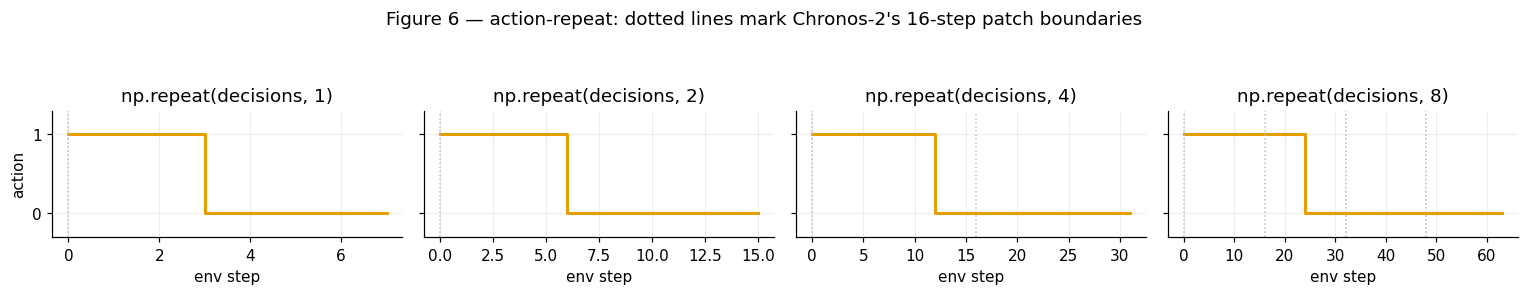

In [20]:
# the action-repeat construction, shown explicitly
rng_demo = np.random.default_rng(0)
decisions = rng_demo.integers(0, 2, 8)
fig, axes = plt.subplots(1, 4, figsize=(14, 2.4), sharey=True)
for ax, k in zip(axes, [1, 2, 4, 8]):
    held = np.repeat(decisions, k)                       # <-- the idea, in one call
    ax.step(np.arange(len(held)), held, where="post", color=C_ALT, lw=2)
    ax.set(title=f"np.repeat(decisions, {k})", ylim=(-.3, 1.3), yticks=[0, 1], xlabel="env step")
    for b in range(0, len(held), 16):
        ax.axvline(b, color="#bbb", ls=":", lw=1)
axes[0].set_ylabel("action")
fig.suptitle("Figure 6 — action-repeat: dotted lines mark Chronos-2's 16-step patch boundaries", y=1.10)
plt.tight_layout(); savefig("idea1-repeat"); plt.show()

In [21]:
K_GRID = [1, 2, 3, 4]                     # k>=8 is not measurable: episodes collapse to ~9 steps
sweep_k = {(a, D): [] for a in ("aligned", "shifted") for D in (0, 8)}
ep_len_k = []
for k in K_GRID:
    pool_k, eval_k = data[("pd-policy", k)]["pool"], data[("pd-policy", k)]["eval"]
    q_k = make_queries(eval_k, N_QUERIES)
    G_k = true_counterfactual(q_k)
    ep_len_k.append(np.mean([len(S) for S, _ in pool_k]))
    msg = f"k={k}  eplen {ep_len_k[-1]:5.0f} |"
    for (a, D) in sweep_k:
        s = sens(predict_counterfactual(q_k, pool_k, D=D, align=a), G_k)
        sweep_k[(a, D)].append(s)
        msg += f"  {a[:3]}/D{D}={s:5.2f}"
    print(msg)

k=1  eplen   201 |  ali/D0= 0.83  ali/D8= 1.01  shi/D0=-0.19  shi/D8=-0.03
k=2  eplen   164 |  ali/D0= 0.42  ali/D8= 0.95  shi/D0= 0.06  shi/D8= 0.03
k=3  eplen    90 |  ali/D0= 0.61  ali/D8= 0.92  shi/D0= 0.10  shi/D8= 0.01
k=4  eplen    79 |  ali/D0= 0.49  ali/D8= 0.91  shi/D0= 0.08  shi/D8= 0.02


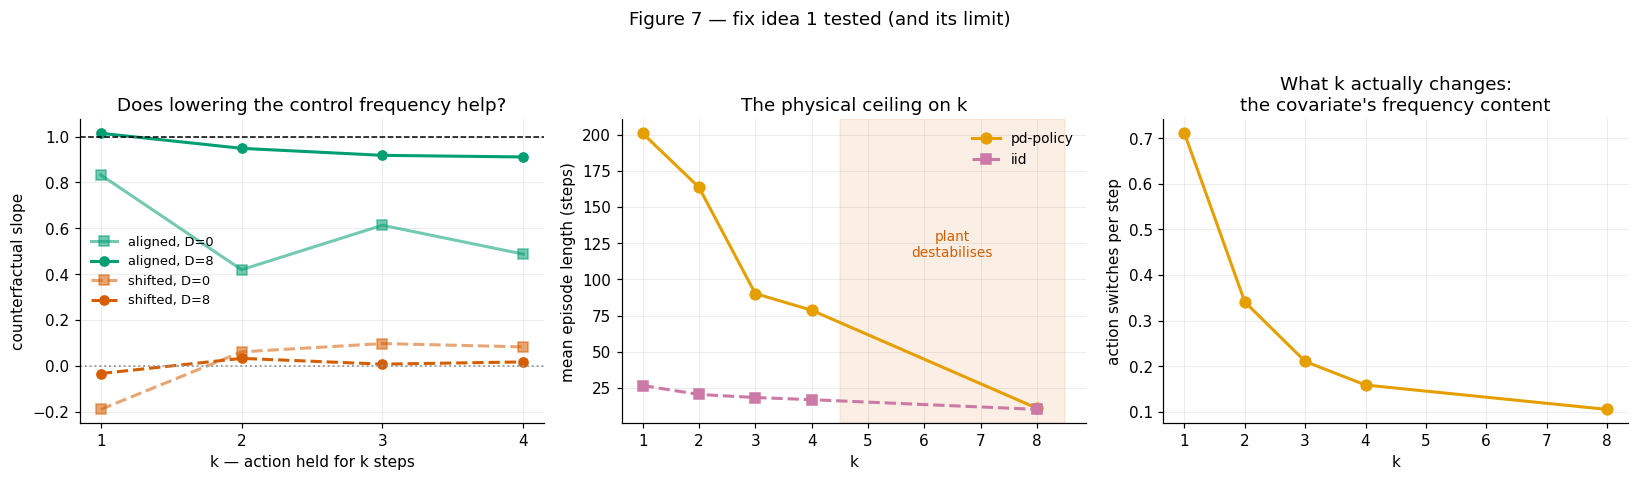

In [22]:
# ------------------------------------------------------------------ Figure 7: idea 1
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for (a, D), v in sweep_k.items():
    ax.plot(K_GRID, v, marker="o" if D else "s", ms=6,
            ls="-" if a == "aligned" else "--",
            color=C_GOOD if a == "aligned" else C_BAD, alpha=1 if D else .55,
            label=f"{a}, D={D}")
ax.axhline(1, color="k", ls="--", lw=1); ax.axhline(0, color="#999", ls=":", lw=1.2)
ax.set(xticks=K_GRID, xlabel="k — action held for k steps",
       ylabel="counterfactual slope", title="Does lowering the control frequency help?")
ax.legend(fontsize=8.5)

ax = axes[1]
k_all = [1, 2, 3, 4, 8]
for nm, ls, mk, cc in [("pd-policy", "-", "o", C_ALT), ("iid", "--", "s", PALETTE[4])]:
    ax.plot(k_all, [np.mean([len(S) for S, _ in data[(nm, k)]["pool"]]) for k in k_all],
            ls, marker=mk, color=cc, ms=7 if mk == "o" else 6, label=nm)
ax.legend(fontsize=9)
ax.axvspan(4.5, 8.5, color=C_BAD, alpha=.10)
ax.text(6.5, ax.get_ylim()[1] * .55, "plant\ndestabilises", ha="center", fontsize=9, color=C_BAD)
ax.set(xlabel="k", ylabel="mean episode length (steps)",
       title="The physical ceiling on k")

ax = axes[2]
sw = [np.mean([np.abs(np.diff(A)).mean() for _, A in data[("pd-policy", k)]["pool"] if len(A) > 1])
      for k in k_all]
ax.plot(k_all, sw, "o-", color=C_ALT, ms=7)
ax.set(xlabel="k", ylabel="action switches per step",
       title="What k actually changes:\nthe covariate's frequency content")
fig.suptitle("Figure 7 — fix idea 1 tested (and its limit)", y=1.03)
plt.tight_layout(); savefig("idea1-frequency"); plt.show()

### Idea 1 does not work here — and the reason is instructive

This is a **negative result**, reported as such:

* With the correct alignment, action-repeat makes things *worse*: at $D=0$ the slope drops from
  **0.83** at $k=1$ to **0.42 / 0.61 / 0.49** at $k = 2, 3, 4$. Holding the action removes
  *variation* from the covariate, and variation is exactly the evidence the model needs in order to
  infer what the covariate does. A context in which the action barely changes is a context with few
  examples of the contrast. (The §2 table makes this concrete: action switches per step fall from
  0.71 at $k=1$ to 0.16 at $k=4$.)
* Under the shifted convention, $k$ does nudge the slope up slightly (**−0.19 → ~0.08**, and
  **−0.01 → 0.17** for the i.i.d. data in §8). That is not the model getting better — it is the
  misalignment being *masked*: when the action is held for $k$ steps, $a_t = a_{t-1}$ with
  probability $(k-1)/k$, so the wrong covariate accidentally carries the right value most of the
  time. Worth knowing, because it means action-repeat can **hide** an alignment bug rather than
  reveal it.
* The lever cannot be pushed anyway: at $k \geq 8$ CartPole terminates in ~10 steps under *both*
  policies, so there is no trajectory left to forecast. An unstable plant cannot be driven slowly.

The underlying hypothesis — "the control signal must be resolvable relative to the patch size" — is
still reasonable, and is exactly the explanation given in §3.4 of the CartPole notebook. What this
experiment shows is that it was **not the binding constraint** at $H=1$: once the covariate is
aligned, Chronos-2 resolves a signal that flips every single step, well inside one patch.

## 7. Do the two levers interact?

Idea 1 and idea 2 are not mutually exclusive, so we sweep them jointly. This is the plot that answers
"should I combine them?".

In [23]:
K_HM, D_HM = [1, 2, 3, 4], [0, 1, 4, 8]
heat = np.full((len(K_HM), len(D_HM)), np.nan)
for i, k in enumerate(K_HM):
    pool_k = data[("pd-policy", k)]["pool"]
    q_k = make_queries(data[("pd-policy", k)]["eval"], 32, seed=1)
    G_k = true_counterfactual(q_k)
    for j, D in enumerate(D_HM):
        heat[i, j] = sens(predict_counterfactual(q_k, pool_k, D=D, align="aligned"), G_k)
    print(f"k={k}: " + "  ".join(f"D={D}:{heat[i,j]:5.2f}" for j, D in enumerate(D_HM)))

k=1: D=0: 0.83  D=1: 0.99  D=4: 1.01  D=8: 1.01
k=2: D=0: 0.36  D=1: 0.78  D=4: 0.92  D=8: 0.96
k=3: D=0: 0.48  D=1: 0.73  D=4: 0.87  D=8: 0.85
k=4: D=0: 0.44  D=1: 0.75  D=4: 0.89  D=8: 0.86


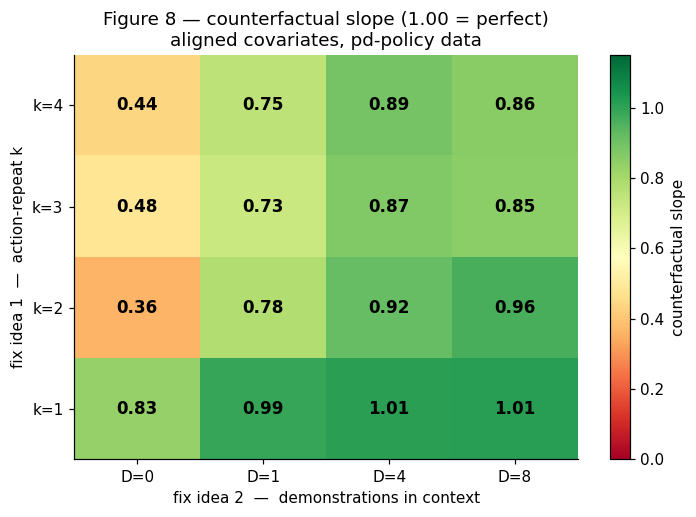

In [24]:
# ------------------------------------------------------------------ Figure 8: interaction heatmap
fig, ax = plt.subplots(figsize=(6.6, 4.8))
im = ax.imshow(heat, cmap="RdYlGn", vmin=0, vmax=1.15, aspect="auto", origin="lower")
ax.set_xticks(range(len(D_HM)), [f"D={d}" for d in D_HM])
ax.set_yticks(range(len(K_HM)), [f"k={k}" for k in K_HM])
for i in range(len(K_HM)):
    for j in range(len(D_HM)):
        ax.text(j, i, f"{heat[i,j]:.2f}", ha="center", va="center", fontsize=11,
                color="k", fontweight="bold")
ax.set(xlabel="fix idea 2  —  demonstrations in context",
       ylabel="fix idea 1  —  action-repeat k",
       title="Figure 8 — counterfactual slope (1.00 = perfect)\naligned covariates, pd-policy data")
plt.colorbar(im, ax=ax, label="counterfactual slope")
ax.grid(False)
plt.tight_layout(); savefig("interaction"); plt.show()

The heatmap reads left-to-right, not bottom-to-top: **the $D$ axis carries essentially all of the
improvement, the $k$ axis carries none.** The two levers do not combine into anything; $k>1$ mainly
costs episode length. If you have a budget for exactly one intervention, spend it on $D$ — and in
fact on $D=1$.

## 8. Non-random actions

All of the above used the exploration-heavy regimes. Does the picture change when the data comes from
a real closed-loop controller — the situation in an actual Dyna / model-based RL loop?

In [25]:
regimes = {"iid random":        data[("iid", 1)],
           "iid, repeat k=4":   data[("iid", 4)],
           "pd-policy":         data[("pd-policy", 1)],
           "pd-policy, k=4":    data[("pd-policy", 4)]}
pol_res = {}
for name, d in regimes.items():
    q = make_queries(d["eval"], N_QUERIES)
    Gq = true_counterfactual(q)
    pol_res[name] = {a: sens(predict_counterfactual(q, d["pool"], D=4, align=a), Gq)
                     for a in ("aligned", "shifted")}
    print(f"{name:18s} aligned {pol_res[name]['aligned']:5.2f}   "
          f"shifted {pol_res[name]['shifted']:5.2f}")

iid random         aligned  1.04   shifted -0.01
iid, repeat k=4    aligned  0.97   shifted  0.17
pd-policy          aligned  1.01   shifted -0.04
pd-policy, k=4     aligned  0.87   shifted  0.07


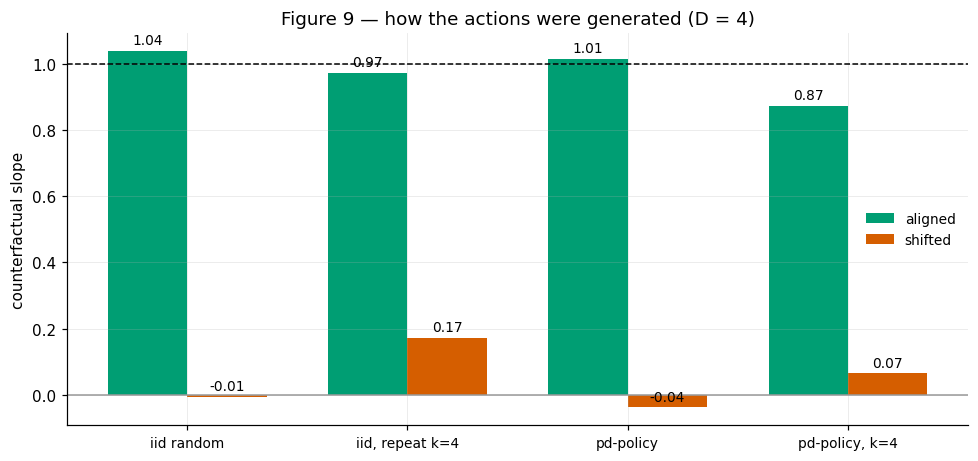

In [26]:
# ------------------------------------------------------------------ Figure 9: policy comparison
fig, ax = plt.subplots(figsize=(9, 4.3))
xs, w = np.arange(len(pol_res)), 0.36
ax.bar(xs - w/2, [v["aligned"] for v in pol_res.values()], w, color=C_GOOD, label="aligned")
ax.bar(xs + w/2, [v["shifted"] for v in pol_res.values()], w, color=C_BAD, label="shifted")
ax.axhline(1, color="k", ls="--", lw=1); ax.axhline(0, color="#999", lw=1)
for i, v in enumerate(pol_res.values()):
    ax.text(i - w/2, v["aligned"] + .02, f"{v['aligned']:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, v["shifted"] + .02, f"{v['shifted']:.2f}", ha="center", fontsize=9)
ax.set_xticks(xs, list(pol_res), fontsize=9)
ax.set(ylabel="counterfactual slope", title="Figure 9 — how the actions were generated (D = 4)")
ax.legend(fontsize=9)
plt.tight_layout(); savefig("policies"); plt.show()

**The action-generating policy barely matters.** With the correct alignment every regime lands at
~0.9–1.0; with the wrong one, every regime lands at ~0. In particular the closed-loop `pd-policy`
data is *not* worse than i.i.d. data, which is reassuring for the model-based RL use case: you can
learn the dynamics in-context from on-policy data.

The caveat from §2 still stands, and this is exactly why we measured a counterfactual: with
closed-loop data the action is a function of the state, so an ordinary forecast-error test could not
have distinguished "uses the action" from "reads the state and guesses the action".

## 9. Redoing the original ablation properly

For continuity with the existing notebooks: the same **random-action ablation** used there
(error with true actions vs. error with randomised actions), now run under both conventions. The
metric is nRMSE, normalised per channel.

In [27]:
def nrmse_with_actions(queries, pool, D, align, mode, H=1, seed=0):
    '''mode: "true" -> real future actions; "random" -> randomised future actions.'''
    rng, tasks, anchors = np.random.default_rng(seed), [], []
    for S, A, t in queries:
        demos = [pool[i] for i in rng.choice(len(pool), D, replace=False)] if D else []
        cf = float(rng.integers(0, 2)) if mode == "random" else None
        tasks.append(build_task(S, A, t, 32, H, demos, align, cf=cf))
        anchors.append(S[t - 1])
    outs = pipe.predict(tasks, prediction_length=H, batch_size=256)
    err = []
    for i, (S, A, t) in enumerate(queries):
        o = np.transpose(outs[i].numpy(), (2, 1, 0))[:, Q50, :]
        err.append((anchors[i] + np.cumsum(o, axis=0) - S[t:t + H]) / SD)
    return float(np.sqrt((np.concatenate(err) ** 2).mean()))

abl = {}
for align in ("aligned", "shifted"):
    for mode in ("true", "random"):
        abl[(align, mode)] = [nrmse_with_actions(q_iid, pool_iid, D, align, mode) for D in D_GRID]
    r = np.array(abl[(align, "random")]) / np.array(abl[(align, "true")])
    print(f"{align:8s} ratio random/true over D={D_GRID}: {r.round(2)}")

aligned  ratio random/true over D=[0, 1, 2, 4, 8, 16]: [ 2.09  9.93 10.04 10.07 10.74 14.01]
shifted  ratio random/true over D=[0, 1, 2, 4, 8, 16]: [1.04 1.12 1.23 0.83 0.95 1.01]


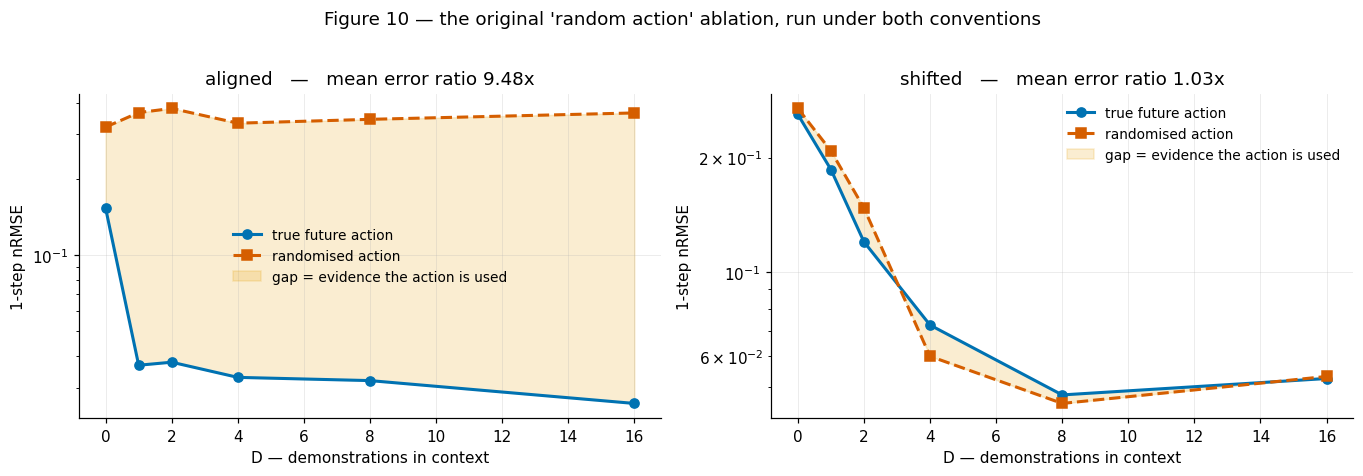

In [28]:
# ------------------------------------------------------------------ Figure 10: the ablation, redone
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, align in zip(axes, ("aligned", "shifted")):
    ax.plot(D_GRID, abl[(align, "true")],   "o-",  color=C_TRUE, ms=6, label="true future action")
    ax.plot(D_GRID, abl[(align, "random")], "s--", color=C_BAD,  ms=6, label="randomised action")
    ax.fill_between(D_GRID, abl[(align, "true")], abl[(align, "random")],
                    color=C_ALT, alpha=.18, label="gap = evidence the action is used")
    r = np.mean(np.array(abl[(align, "random")]) / np.array(abl[(align, "true")]))
    ax.set(xlabel="D — demonstrations in context", ylabel="1-step nRMSE", yscale="log",
           title=f"{align}   —   mean error ratio {r:.2f}x")
    ax.legend(fontsize=9)
fig.suptitle("Figure 10 — the original 'random action' ablation, run under both conventions", y=1.02)
plt.tight_layout(); savefig("ablation"); plt.show()

The original ablation now behaves the way an ablation should. Under `aligned`, feeding a randomised
action costs a factor of **10–14×** in error once demonstrations are present. Under `shifted` the two
curves lie on top of each other (ratio **0.83–1.23**, i.e. noise around 1.0), reproducing the
published null result exactly. Same model, same data — the conclusion flips with a one-index change
in the harness.

Note also the `aligned`, $D=0$ point: the ratio there is only 2.1×, versus ~10× from $D=1$ onward.
Both fixes show up in this metric too.

## 10. Multi-step counterfactual rollout

The most direct picture of "is this a usable dynamics model": freeze a real context, then forecast
12 steps ahead **twice** — once under "always push left", once under "always push right" — in a
single forward pass (direct multi-horizon, no autoregression). Overlay the true trajectories.
If the model is action-blind the two forecasts coincide.

In [29]:
H_ROLL = 12
q_roll = make_queries(data[("pd-policy", 1)]["eval"], 3, seed=7, H=H_ROLL)
pool_pd = data[("pd-policy", 1)]["pool"]
rng = np.random.default_rng(0)
demos_roll = [pool_pd[i] for i in rng.choice(len(pool_pd), 4, replace=False)]

roll = {}
for a_const in (0.0, 1.0):
    # under "aligned", the covariates for s_t..s_{t+H-1} are a_{t-1}..a_{t+H-2}: overwrite exactly
    # those with the constant action, leaving the context's real actions untouched.
    tasks = [build_task(S, np.concatenate([A[:t - 1], np.full(H_ROLL, a_const, np.float32)]),
                        t, 32, H_ROLL, demos_roll, "aligned") for S, A, t in q_roll]
    outs = pipe.predict(tasks, prediction_length=H_ROLL, batch_size=64)
    pred = np.array([q_roll[i][0][q_roll[i][2] - 1]
                     + np.cumsum(np.transpose(o.numpy(), (2, 1, 0))[:, Q50, :], 0)
                     for i, o in enumerate(outs)])
    truth = []
    for S, A, t in q_roll:
        s, tr = S[t - 1], []
        for _ in range(H_ROLL):
            s = cartpole_step(s, a_const); tr.append(s)
        truth.append(tr)
    roll[a_const] = (pred, np.array(truth, np.float32))
print("rolled out", len(q_roll), "contexts x 2 action sequences x", H_ROLL, "steps")

rolled out 3 contexts x 2 action sequences x 12 steps


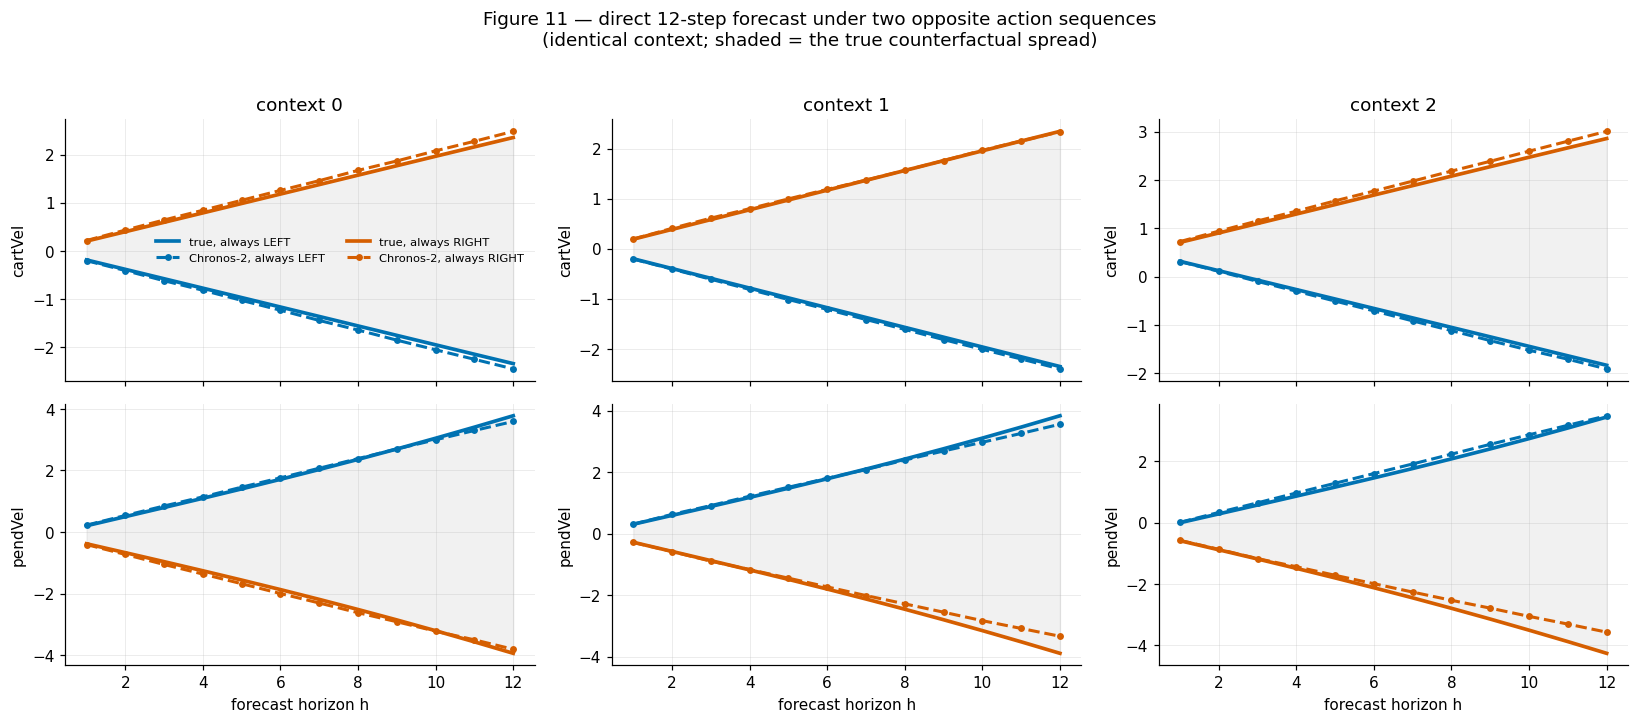

action sequence  cartPos  cartVel  pendPos  pendVel  mean
    always LEFT     0.62    0.098    1.742    0.124 0.646
   always RIGHT     0.65    0.124    1.739    0.298 0.703

mean separation between the two action sequences (velocity channels):
  true  3.271
  model 3.276   ->  100% of the true spread


In [30]:
# ------------------------------------------------------------------ Figure 11: counterfactual rollout
fig, axes = plt.subplots(2, 3, figsize=(15, 6.4), sharex=True)
xs = np.arange(1, H_ROLL + 1)
for col in range(3):
    for row, j in enumerate(VEL):
        ax = axes[row][col]
        for a_const, col_c, nm in [(0.0, C_TRUE, "always LEFT"), (1.0, C_BAD, "always RIGHT")]:
            pred, truth = roll[a_const]
            ax.plot(xs, truth[col, :, j], color=col_c, lw=2.4, label=f"true, {nm}")
            ax.plot(xs, pred[col, :, j], color=col_c, lw=2, ls="--", marker="o", ms=3.5,
                    label=f"Chronos-2, {nm}")
        ax.fill_between(xs, roll[0.0][1][col, :, j], roll[1.0][1][col, :, j],
                        color="#999", alpha=.13)
        ax.set_ylabel(STATE[j])
        if row == 0: ax.set_title(f"context {col}")
        if row == 1: ax.set_xlabel("forecast horizon h")
axes[0][0].legend(fontsize=7.5, ncol=2)
fig.suptitle("Figure 11 — direct 12-step forecast under two opposite action sequences\n"
             "(identical context; shaded = the true counterfactual spread)", y=1.02)
plt.tight_layout(); savefig("rollout"); plt.show()

rows = []
for a_const, nm in [(0.0, "always LEFT"), (1.0, "always RIGHT")]:
    pred, truth = roll[a_const]
    e = np.sqrt((((pred - truth) / SD) ** 2).mean(axis=(0, 1)))      # per channel
    rows.append([nm] + list(e.round(3)) + [round(float(e.mean()), 3)])
print(pd.DataFrame(rows, columns=["action sequence"] + STATE + ["mean"]).to_string(index=False))

sep_true = np.abs(roll[0.0][1] - roll[1.0][1])[:, :, VEL].mean()
sep_pred = np.abs(roll[0.0][0] - roll[1.0][0])[:, :, VEL].mean()
print(f"\nmean separation between the two action sequences (velocity channels):")
print(f"  true  {sep_true:.3f}\n  model {sep_pred:.3f}   ->  {sep_pred/sep_true:.0%} of the true spread")

### Reading the rollout: the action effect is right, the level drifts

Two numbers that say different things:

* The **separation** between the two forecasts — how far "always left" and "always right" pull apart —
  is **3.276** against a true separation of **3.271**, i.e. **100 %** of the true counterfactual
  spread, sustained over all 12 steps in a single forward pass. For a *planner* this is the property
  that matters: candidate action sequences are ranked correctly.
* The **absolute** error is nonetheless substantial, and the per-channel table shows where it lives:
  the two velocity channels (the ones the action acts on directly, plotted above) track closely,
  while `cartPos` / `pendPos` carry most of the error because they **integrate** the velocity error
  over the horizon.

So action-conditioning and long-horizon accuracy are separable failure modes, and only the first is
what this notebook set out to measure. The drift is also unsurprising on its own terms: "push in one
direction for 12 straight steps" drives CartPole far outside the region the context demonstrates —
the pole topples — so the model is extrapolating off-distribution. That is a data-coverage problem
and the same compounding-error story as §3.5 of the CartPole notebook, not a new one.

## 11. Summary

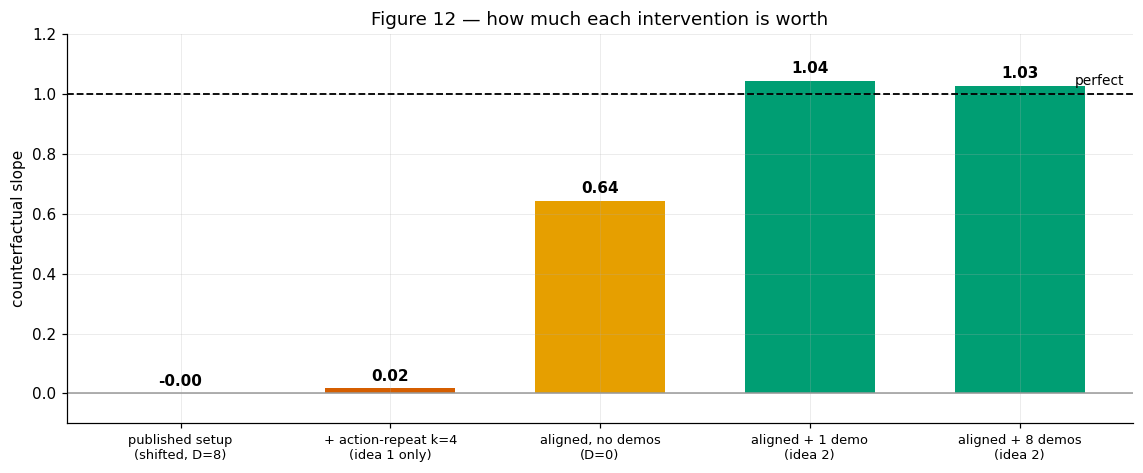

In [31]:
# ------------------------------------------------------------------ Figure 12: everything at a glance
summary = {
    "published setup\n(shifted, D=8)":      sweep_D["shifted"][D_GRID.index(8)][VEL].mean(),
    "+ action-repeat k=4\n(idea 1 only)":   sweep_k[("shifted", 8)][K_GRID.index(4)],
    "aligned, no demos\n(D=0)":             sweep_D["aligned"][0][VEL].mean(),
    "aligned + 1 demo\n(idea 2)":           sweep_D["aligned"][D_GRID.index(1)][VEL].mean(),
    "aligned + 8 demos\n(idea 2)":          sweep_D["aligned"][D_GRID.index(8)][VEL].mean(),
}
fig, ax = plt.subplots(figsize=(10.5, 4.4))
cols = [C_BAD, C_BAD, C_ALT, C_GOOD, C_GOOD]
bars = ax.bar(range(len(summary)), list(summary.values()), color=cols, width=.62)
ax.axhline(1, color="k", ls="--", lw=1.2); ax.text(4.5, 1.03, "perfect", ha="right", fontsize=9)
ax.axhline(0, color="#999", lw=1)
for b, v in zip(bars, summary.values()):
    ax.text(b.get_x() + b.get_width()/2, v + .025, f"{v:.2f}", ha="center", fontweight="bold")
ax.set_xticks(range(len(summary)), list(summary), fontsize=8.5)
ax.set(ylabel="counterfactual slope", ylim=(-.1, 1.2),
       title="Figure 12 — how much each intervention is worth")
plt.tight_layout(); savefig("summary"); plt.show()

### What we found

1. **The "TSFM is action-blind" result on CartPole was a harness artifact, not a model property.**
   The action covariate was offset by one step against the state it was meant to explain. Under that
   convention the model is asked whether $a_t$ moves $s_t$, and the physically correct answer is
   "no" — so the ablation had to come back null. Fixing the index takes the counterfactual slope from
   **−0.001 to 1.029** (cartVel) with no other change, and the random-action error ratio from
   **1.0× to 10.7×**.

2. **Fix idea 2 (more demonstrations in context) works, and saturates immediately.** Aligned and with
   no demos the slope is already **0.67**; **one** stitched demonstration reaches **1.04**. $D=16$ is
   no better than $D=1$ and costs ~10× the context. Useful side effect: if adding in-context examples
   moves a covariate metric *not at all*, that is a strong hint the harness is broken rather than the
   model.

3. **Fix idea 1 (action-repeat via `np.repeat`) does not help on CartPole — a clean negative result.**
   Holding the action *reduces* the covariate variation the model learns from, so the $D=0$ slope
   drops from **0.83** ($k=1$) to **0.42–0.61** ($k\ge2$). It also cannot be pushed: at $k\ge8$ the
   pole falls within ~10 steps, because an unstable plant cannot be driven slowly. It does slightly
   raise the *shifted* slope — but only by masking the misalignment ($a_t = a_{t-1}$ most of the
   time), which makes action-repeat a way to **hide** this bug rather than find it.

4. **Non-random actions are fine.** Data from a closed-loop controller gives the same slope
   (**1.01**) as i.i.d. data (**1.04**). Because the measurement is a counterfactual, this is not
   contaminated by the action–state confounding that would break a plain forecast-error test on
   on-policy data.

### What this does *not* show

This notebook is about the **one-step counterfactual**, i.e. whether the covariate pathway carries
the action at all. It does not overturn the other findings:

* the autoregressive rollout in §3.5 of the CartPole notebook still compounds error, and §10 here
  shows the same split — the *action effect* is captured at 100 % while the *absolute level* drifts
  once the forced action sequence pushes the system off-distribution;
* the accuracy ceiling versus a trained MLP at $N=1000$ episodes is unaffected;
* **Pendulum is a genuinely different case.** `pendulum.py` already uses the aligned convention, so
  its flat slope is *not* explained by this bug. There the action moves $\dot\theta$ by 0.15 out of a
  $\pm 8$ range — under 2 % of the series scale, against the 66–72 % measured here in §3. The honest
  next experiment is to re-run Pendulum Test 2 in **difference space** with **stitched
  demonstrations** (the two ingredients this notebook found to matter) and see whether the slope
  moves off zero.

### The revised claim

Not *"a TSFM cannot be a dynamics model for RL"*, but:

> A TSFM can recover a one-step controllable dynamics model **zero-shot and essentially exactly**
> (slope 1.03 against a ground truth of 1.00), provided the action covariate is causally aligned with
> the state it explains, the target is modelled in difference space, and at least one demonstration
> of the transition is in the context. What remains genuinely hard is *multi-step autoregressive*
> rollout and *small-effect-size* control signals — not action-conditioning as such.